# SVM BINARY CLASSIFIER FROM SCRATCH WITH JAX
SVMs are a supervised machine learning algorithms used for classification and regression tasks. They work by finding the optimal hyperplane that separates data points of different classes with the maximum margin.

As sci-kit learn is converting our jax.numpy inputs to numpy, we will implement a SVM model optimized for Jax from scratch.
# ___________________________________________


# SETUP 

In [ ]:
import sys
print(sys.executable)
print(sys.path)
import jax
import jax.numpy as np
sys.path.insert(0,"2526_INFOB318_Kernax/project/SVM")
from jax import jit
from functools import partial
from Kernax import LinearKernel, SEMagmaKernel
import optax

# Predictions methods and kernels impact

Without kernel(linear)


In [ ]:
def predict_linear(self, X):
    """Simple scalar product : w·x + b"""
    return np.sign(np.dot(X, self.w) + self.b)

With Kernels

In [ ]:
def predict_kernel(self, X):
    """Somme pondérée des similarités kernel"""
    # Similarities between X and the training points
    K_test = self.kernel_fn(X, self.X_train)  # (n_test, n_train)
    
    #  Ponderation by α·y(the importance of each training point)
    weighted_similarities = self.alpha * self.y_train  # (n_train,)
    
    # 3. Sum + Bias
    decisions = np.dot(K_test, weighted_similarities) + self.b
    return np.sign(decisions)

# What it changes concrectly


Without Kernels :
The prediction is made by sign(w·x + b)

With Kernels : 
The prediction is made by sign(∑ αᵢ yᵢ K(x, xᵢ) + b) which means the combination of support vectors

 


# Predict function
Our predict function is classic, for both the dual and primal problem we will simply calculate the label of a given test point based on the output of a decision function

In [ ]:
 @partial(jit, static_argnums=(0,))
 def predict(self, X):
        if(self.kernel == 'squarexpo'):
            assert self.alpha is not None, "if there is no alphas then the model wasn't trained "
            assert self.X_train is not None, "no data points"
            
            # Kernel matrix between X and the training points
            K_test = self.kernel_fn(X, self.X_train)
            
            # decision function of dual problems
            decisions = np.dot(K_test, self.alpha * self.y_train) + self.b
            return np.sign(decisions)

            

        prediction = np.dot(X, self.w) + self.b
        return np.sign(prediction)

# Gradient adam algorithm jit possibilites and details.
The Adam optimizer.

Adam is an SGD variant with gradient scaling adaptation. The scaling used for each parameter is computed from estimates of first and second-order moments of the gradients (using suitable exponential moving averages).

So basically here for the primal problem,
The optimizer will calculate the updates(the gradients for our weight and bias) and add them to the old values of w and b, to compute the new ones.

For the dual problem it will be the same logic but applied to alpha.



# Square expo
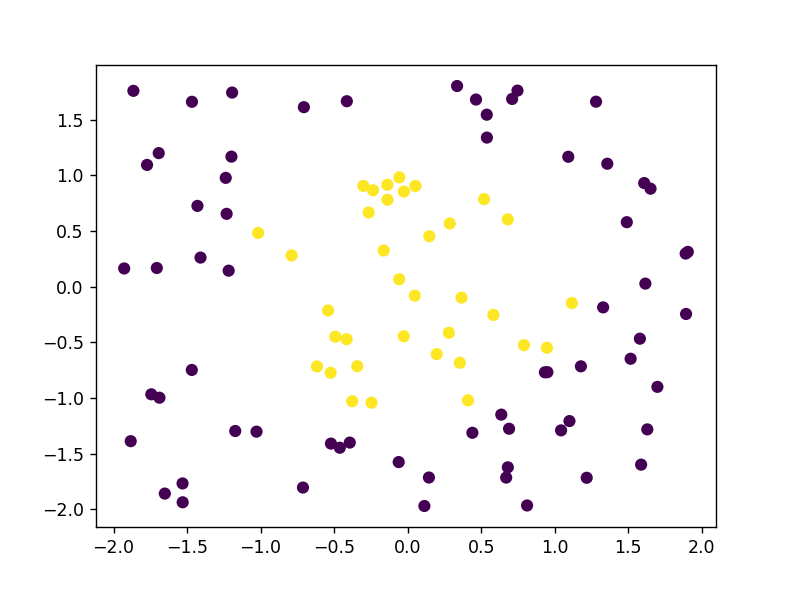
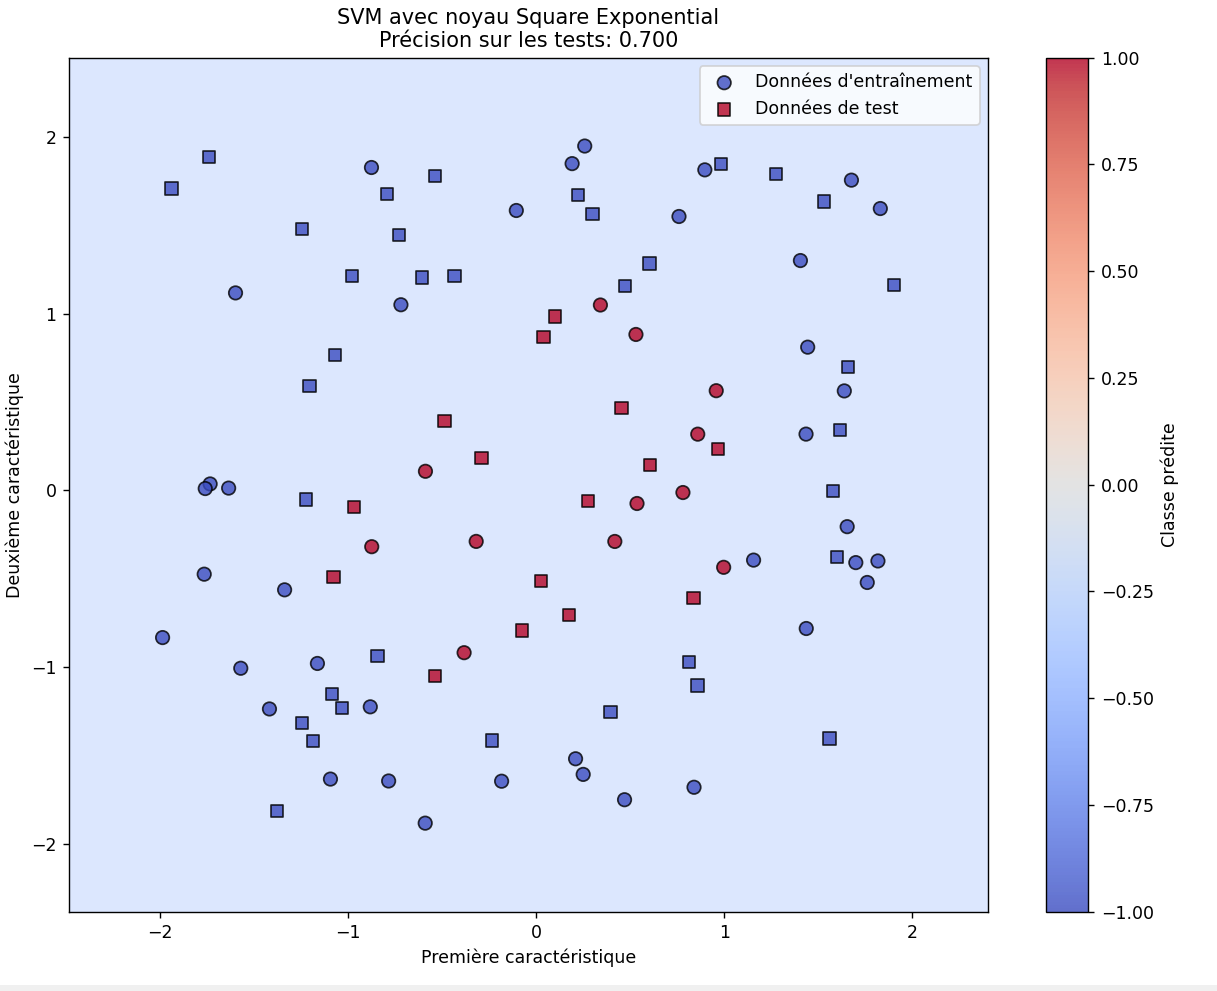